# Variance97 — Phase 3: Machine Learning Model
## Predicting Whether McDavid Goes Pointless Based on Game Context

This notebook builds a logistic regression classifier to predict 
whether Connor McDavid will go pointless in a given game based on 
engineered features derived from game context, playoff round, and 
elimination status.

### Why Logistic Regression?
Logistic regression is appropriate here because our target variable 
is binary — McDavid either goes pointless or he doesn't. It is also 
highly interpretable, meaning the model coefficients directly tell 
us which features most strongly predict a pointless game. 
Interpretability matters here because the goal is not just 
prediction but understanding.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report


In [5]:
mcdavid_df = pd.read_csv('../data/mcdavid_game_log_clean.csv')
mcdavid_df['result'] = mcdavid_df['result'].str.strip()
mcdavid_df.head(10)

,date,opponent,goals,assists,points,plus_minus,SOG,TOI,result,team_score,opp_score,game_number,game_context,season,is_elimination_game
0,2024-06-08,FLA,0,0,0,-2,6.0,25.316667,L,0,3,1.0,stanley_cup_finals,2023-24,False
1,2024-06-10,FLA,0,1,1,1,3.0,25.983333,L,1,4,2.0,stanley_cup_finals,2023-24,False
2,2024-06-13,FLA,0,2,2,1,5.0,25.233333,L,3,4,3.0,stanley_cup_finals,2023-24,False
3,2024-06-15,FLA,1,3,4,2,2.0,17.450000,W,8,1,4.0,stanley_cup_finals,2023-24,True
4,2024-06-18,FLA,2,2,4,2,2.0,24.616667,W,5,3,5.0,stanley_cup_finals,2023-24,True
5,2024-06-21,FLA,0,0,0,1,0.0,18.966667,W,5,1,6.0,stanley_cup_finals,2023-24,True
6,2024-06-24,FLA,0,0,0,0,2.0,25.700000,L,1,2,7.0,stanley_cup_finals,2023-24,True
7,2025-06-04,FLA,0,2,2,0,4.0,31.200000,W,4,3,1.0,stanley_cup_finals,2024-25,False
8,2025-06-06,FLA,0,3,3,0,7.0,35.116667,L,4,5,2.0,stanley_cup_finals,2024-25,False
9,2025-06-09,FLA,0,0,0,-1,2.0,20.850000,L,1,6,3.0,stanley_cup_finals,2024-25,False


In [6]:
mcdavid_df['is_pointless'] = (mcdavid_df['points'] == 0).astype(int)
print(mcdavid_df['is_pointless'].value_counts())

is_pointless
0    312
1     62
Name: count, dtype: int64


In [11]:
mcdavid_df['game_number'] = mcdavid_df['game_number'].fillna(0)

features = ['game_number', 'game_context', 'is_elimination_game', 'season']
target = 'is_pointless'

X = pd.get_dummies(mcdavid_df[features], ['game_context', 'season'])
y = mcdavid_df[target]

print(X.shape)
print(X.columns.tolist())

(374, 18)
['game_number', 'is_elimination_game', 'game_context_conf_finals', 'game_context_first_round', 'game_context_four_nations_faceoff_finals', 'game_context_four_nations_faceoff_group', 'game_context_olympics_exhibition', 'game_context_olympics_finals', 'game_context_olympics_quarterfinals', 'game_context_olympics_semifinals', 'game_context_regular_season', 'game_context_second_round', 'game_context_stanley_cup_finals', 'season_2021-22', 'season_2022-23', 'season_2023-24', 'season_2024-25', 'season_2025-26']


In [19]:
train_seasons = ['2021-22', '2022-23', '2023-24']
test_seasons = ['2024-25', '2025-26']

train_mask = mcdavid_df['season'].isin(train_seasons)
test_mask = mcdavid_df['season'].isin(test_seasons)

X_train = X[train_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Training pointless games: {y_train.sum()}")
print(f"Test pointless games: {y_test.sum()}")

Training set: (291, 18)
Test set: (83, 18)
Training pointless games: 47
Test pointless games: 15


In [22]:
model = LogisticRegression(
    class_weight = 'balanced',
    max_iter = 1000,
    random_state = 42
)
model.fit(X_train, y_train)
print("Model trained successfully")

Model trained successfully


In [25]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names = ['Not Pointless', 'Pointless']))

               precision    recall  f1-score   support

Not Pointless       0.82      0.81      0.81        68
    Pointless       0.19      0.20      0.19        15

     accuracy                           0.70        83
    macro avg       0.50      0.50      0.50        83
 weighted avg       0.71      0.70      0.70        83



### Interpretation
The model ends up with an accuracy score of 70%. In many contexts, this may sound like a great accuracy score for an ML model, however in the context of this project, 70% is actually worse than what we should expect. Based on the games that we drew from, 62 pointless games vs. 312 non-pointless games, a naive classifier that simply predicts 'not pointless' for every game would achieve 82% accuracy, meaning our model's 70% accuracy is actually worse than doing nothing. This means that the pointless class performance is poor, the model is struggling to identify games when McDavid goes pointless. But this makes sense, our current features selected have some signal but are very limited in predictive power for individual game outcomes. This exemplifies the very random nature of hockey, game context alone doesn't fully determine how a certain player may perform in their next game. Despite the weak predictive performance, the model's learned coefficients reveal which game contexts most strongly push McDavid toward a pointless game, which is the more analytically valuable output for this project.

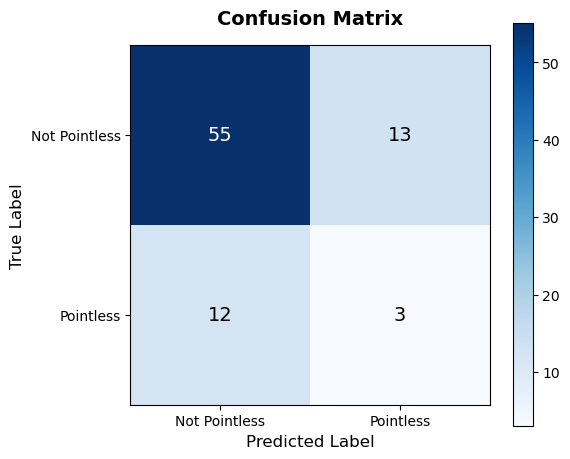

In [27]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize = (6, 5))

im = ax.imshow(cm, interpolation='nearest', cmap = 'Blues')
plt.colorbar(im)

ax.set_title('Confusion Matrix', fontsize = 14, fontweight = 'bold', pad = 15)
ax.set_xlabel('Predicted Label', fontsize = 12)
ax.set_ylabel('True Label', fontsize = 12)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Not Pointless', 'Pointless'])
ax.set_yticklabels(['Not Pointless', 'Pointless'])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha = 'center', va = 'center', fontsize = 14, color = 'white' if cm[i, j] > cm.max() / 2 else 'black')

plt.tight_layout()
plt.show()

### Interpretation
The plot displays the confusion matrix of this problem with True Positives, False Positives, True Negatives, False Negatives. In the context of McDavid going pointless or not, the outcomes are defined as followed:
- True Positive: McDavid went pointless, model predicted pointless
- False Positive: McDavid went non-pointless, model predicted pointless
- True Negative: McDavid went non-pointless, model predicted non-pointless
- False Negative: McDavid went pointless, model predicted non-pointless

The model correctly identified only 3 out of 15 actual pointless games (20% recall) while missing 12, confirming the classification report finding that the pointless class is severely underdetected. The model still needs to be adjusted as there are too many False Negatives, the most detrimental error to our scenario. In this context a false negative means the model failed to flag a game where McDavid actually disappeared, the exact scenario this project is designed to understand and predict.

In [36]:
feature_names = X.columns.tolist()
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
}).sort_values('coefficient', ascending= False)

coef_df

,feature,coefficient
12,game_context_stanley_cup_finals,0.671628
13,season_2021-22,0.341942
11,game_context_second_round,0.188589
15,season_2023-24,0.137637
1,is_elimination_game,0.097129
0,game_number,0.001665
5,game_context_four_nations_faceoff_group,0.000000
4,game_context_four_nations_faceoff_finals,0.000000
7,game_context_olympics_finals,0.000000
6,game_context_olympics_exhibition,0.000000


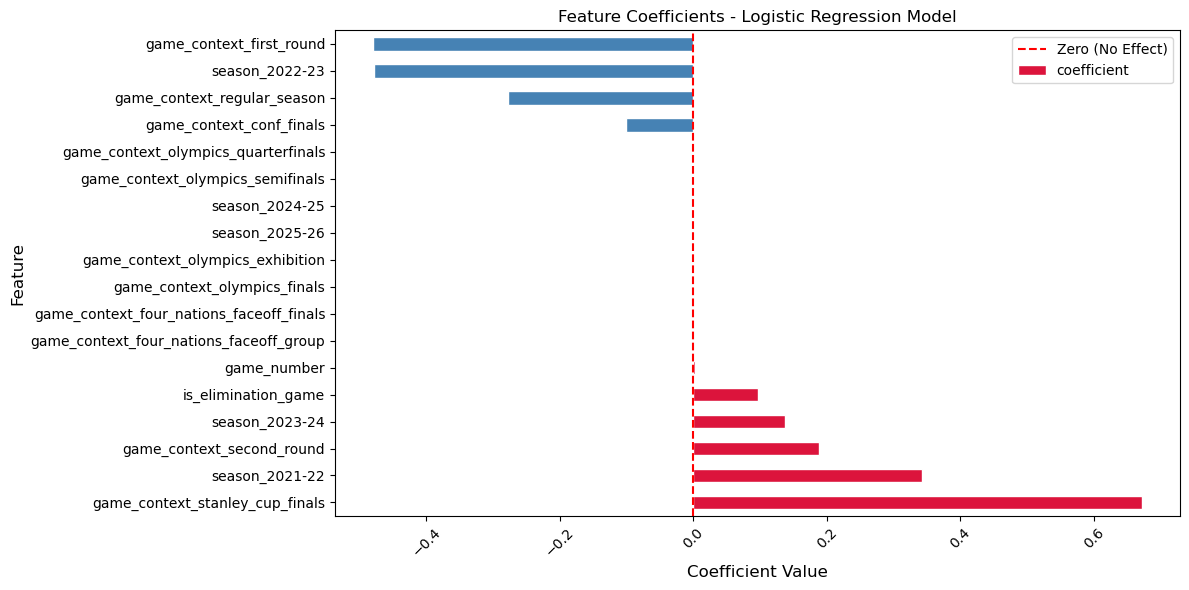

In [37]:
coef_df = coef_df.set_index('feature')
colors = ['crimson' if val >= 0 else 'steelblue' for val in coef_df['coefficient']]

fig, ax = plt.subplots(figsize = (12, 6))

coef_df['coefficient'].plot(
    kind = 'barh',
    ax = ax,
    color = colors,
    edgecolor = 'white',
    legend = False
)

ax.set_title('Feature Coefficients - Logistic Regression Model')
ax.set_xlabel('Coefficient Value', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.axvline(x=0, 
           color='red', linestyle='--', linewidth=1.5, 
           label='Zero (No Effect)')
ax.legend()

plt.tight_layout()
plt.show()

### Interpretation
The plot displays the game context of Stanley Cup Finals is the dominant positive feature in terms of predicting when McDavid goes pointless, a direct validation of H1 and H3 from the Phase 1 EDA. The first round and regular season are by far the strongest negative features, indicating that McDavid is substantially less likely to go pointless in the earlier rounds of the playoffs and regular season. This finding is actually consistent with the Phase 1 findings in which we utilized descriptive statistics and visualizations in order to derive meaning out of McDavid's game log. Additionally, in game contexts where McDavid is facing elimination, the model accurately predicted that he would be more likely to go pointless, a finding consistent with the analysis on McDavid's overall performances in elimination games. In the plot you will also notice that there are zero coefficients for the Four Nations Faceoff and Olympics. The zero coefficients for Four Nations and Olympics contexts reflect the chronological train/test split as the model was trained on 2021-24 seasons and never encountered these international contexts during training, so it learned nothing about them. This is a known limitation of the chronological approach rather than a deliberate design choice. This plot stands as the strongest in this data analysis pipeline by far. This convergence across three independent methodologies, descriptive statistics, hypothesis testing, and machine learning, substantially strengthens the conclusion that the Stanley Cup Finals context is the single strongest predictor of McDavid going pointless, lending credibility to H3 as the most supported hypothesis in this analysis. 